
Threshold | Recall | Precision | FP | FN
    0.35 | 0.770 | 0.770 | 17 | 17
     0.4 | 0.743 | 0.786 | 15 | 19
    0.45 | 0.716 | 0.791 | 14 | 21
    0.47 | 0.703 | 0.800 | 13 | 22
     0.5 | 0.703 | 0.800 | 13 | 22
    0.55 | 0.689 | 0.810 | 12 | 23

Final Accuracy: 81.00558659217877
Confusion Matrix:
 [[88 17]
 [17 57]]

BEST THRESHOLD: 0.35
[[88 17]
 [17 57]]


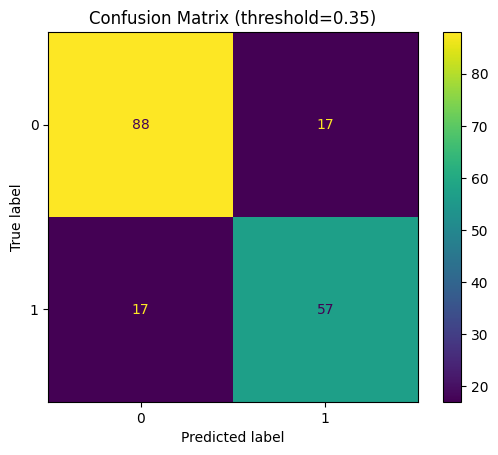

In [206]:
#Random forest

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    recall_score,
    precision_score
)


train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# feature engineering
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1
test_data["FamilySize"] = test_data["SibSp"] + test_data["Parch"] + 1

train_data["IsAlone"] = (train_data["FamilySize"] == 1).astype(int)
test_data["IsAlone"] = (test_data["FamilySize"] == 1).astype(int)

# features
y = train_data["Survived"]

features = [
    "Pclass", "Sex", "SibSp", "Parch",
    "Age", "Fare", "Embarked",
    "FamilySize", "IsAlone"
]

X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

# column alignment
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=1
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_val)[:, 1]



# Threshold tuning (recall)
best_t = 0
best_recall = 0

print("\nThreshold | Recall | Precision | FP | FN")

for t in [0.35, 0.4, 0.45, 0.47, 0.5, 0.55]:
    y_pred_t = (y_prob > t).astype(int)

    recall = recall_score(y_val, y_pred_t)
    precision = precision_score(y_val, y_pred_t)
    cm = confusion_matrix(y_val, y_pred_t)

    TN, FP, FN, TP = cm.ravel()

    print(f"{t:8} | {recall:.3f} | {precision:.3f} | {FP} | {FN}")

    # Keeping FN low but control FP FN are more sensitive to data FP is acceptable to model
    if recall > best_recall and precision > 0.65:
        best_recall = recall
        best_t = t



# evaluation
threshold = best_t
y_pred = (y_prob > threshold).astype(int)

print("\nFinal Accuracy:", accuracy_score(y_val, y_pred)*100)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

print("\nBEST THRESHOLD:", best_t)


model.fit(X_train, y_train)
y_prob = model.predict_proba(X_val)[:, 1]

cm = confusion_matrix(y_val, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix (threshold={threshold})")
plt.show()

# model on full data
model.fit(X, y)

test_prob = model.predict_proba(X_test)[:, 1]
test_pred = (test_prob > threshold).astype(int)


output = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": test_pred
})

# output.to_csv("submission.csv", index=False)

In [197]:
# False Negatives: survived in actual but model is showing dies its sensitive in this particular case
val_data = train_data.iloc[X_val.index].copy()

val_data["Actual"] = y_val.values
val_data["Predicted"] = y_pred


false_negatives = val_data[
    (val_data["Predicted"] == 0) &
    (val_data["Actual"] == 1)
]

print(false_negatives[["PassengerId", "Survived","Predicted"]].to_string(index=False))

 PassengerId  Survived  Predicted
         710         1          0
         622         1          0
         448         1          0
         674         1          0
         205         1          0
          24         1          0
         713         1          0
         339         1          0
         287         1          0
         210         1          0
         513         1          0
         605         1          0
          66         1          0
         644         1          0
         508         1          0
         573         1          0
          26         1          0


In [198]:
#checking False positives: died but model is predicting survived

# Create comparison DataFrame
results = X_val.copy()
results["Actual"] = y_val.values
results["Predicted"] = y_pred
val_data = train_data.iloc[X_val.index].copy()

val_data["Actual"] = y_val.values
val_data["Predicted"] = y_pred


false_positives = val_data[
    (val_data["Predicted"] == 1) &
    (val_data["Actual"] == 0)
]

print(false_positives[["PassengerId","Survived","Predicted"]].to_string(index=False))



 PassengerId  Survived  Predicted
         397         0          1
         236         0          1
         363         0          1
         660         0          1
         773         0          1
         313         0          1
         768         0          1
         358         0          1
         255         0          1
         175         0          1
         140         0          1
         579         0          1
          50         0          1
         855         0          1
         658         0          1
          55         0          1
         853         0          1


In [199]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# load data
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# target
y = train_data["Survived"]

# features
features = ["Pclass", "Sex", "SibSp", "Parch"]

X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

# align columns (important safety step)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# model
model = LogisticRegression(max_iter=500)

# cross-validation (ONLY on training data)
scores = cross_val_score(model, X, y, cv=5)
print("CV Accuracy:", scores.mean()*100)

# train full model
model.fit(X, y)

# predict test
predictions = model.predict(X_test)

# output file
output = pd.DataFrame({
    'PassengerId': test_data.PassengerId,
    'Survived': predictions
})

# output.to_csv('submission_logreg.csv', index=False)
# print("Submission saved!")

CV Accuracy: 79.9083547799887


In [200]:
#SVM accuracy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)

y = train_data["Survived"] #target
features = ["Pclass", "Sex", "SibSp", "Parch", "Age", "Fare", "Embarked"] #features
X = train_data[features].copy()
X_test = test_data[features].copy()

# Handle missing values
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

X_test["Age"] = X_test["Age"].fillna(X["Age"].median())
X_test["Fare"] = X_test["Fare"].fillna(X["Fare"].median())
X_test["Embarked"] = X_test["Embarked"].fillna(X["Embarked"].mode()[0])

# One-hot encoding
X = pd.get_dummies(X)
X_test = pd.get_dummies(X_test)

# align columns (VERY IMPORTANT)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# Scaling (CRITICAL for SVM)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Hyperparameter tuning
param_grid = {
    "C": [0.5, 1, 5, 10],
    "gamma": [0.01, 0.1, "scale"],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


# Validation accuracy
val_pred = best_model.predict(X_val)
acc = accuracy_score(y_val, val_pred)

print("Validation Accuracy:", acc*100)

# Train final model
best_model.fit(X_scaled, y)

# Predict test data
predictions = best_model.predict(X_test_scaled)

# Submission file
output = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": predictions
})

# output.to_csv("svm_submission.csv", index=False)

# print("Submission file created successfully!")


Best Parameters: {'C': 5, 'gamma': 0.1, 'kernel': 'rbf'}
Validation Accuracy: 81.56424581005587



MODEL COMPARISON (CORRECT)

Random Forest       : 82.49%
SVM                 : 82.60%
Logistic Regression : 79.13%


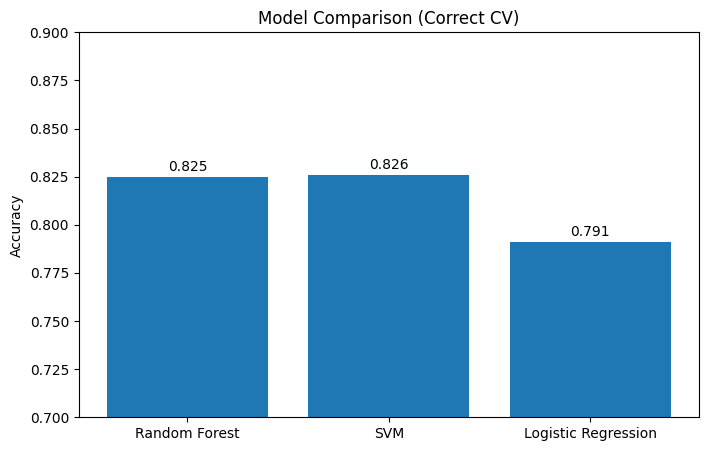

In [201]:
#comparision of all models
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


train_data = pd.read_csv("train.csv")

# feature engineering
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1
train_data["IsAlone"] = (train_data["FamilySize"] == 1).astype(int)

y = train_data["Survived"]

features = [
    "Pclass", "Sex", "SibSp", "Parch",
    "Age", "Fare", "Embarked",
    "FamilySize", "IsAlone"
]

X = pd.get_dummies(train_data[features])

# fill missing
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())

# align safety
X, _ = X.align(X, join='left', axis=1, fill_value=0)

# scaling svm
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# models
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
svm = SVC(kernel='rbf', C=1, gamma='scale')
lr = LogisticRegression(max_iter=500)

#cross validation
rf_score = cross_val_score(rf, X, y, cv=5).mean()
svm_score = cross_val_score(svm, X_scaled, y, cv=5).mean()   # IMPORTANT FIX
lr_score = cross_val_score(lr, X, y, cv=5).mean()

print("\nMODEL COMPARISON (CORRECT)\n")
print(f"Random Forest       : {rf_score*100:.2f}%")
print(f"SVM                 : {svm_score*100:.2f}%")
print(f"Logistic Regression : {lr_score*100:.2f}%")

models = ["Random Forest", "SVM", "Logistic Regression"]
scores = [rf_score, svm_score, lr_score]

plt.figure(figsize=(8,5))
bars = plt.bar(models, scores)

plt.title("Model Comparison (Correct CV)")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.9)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.003,
        f"{yval:.3f}",
        ha='center'
    )

plt.show()